In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
pd.set_option("display.max_columns", None)
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=DeprecationWarning)
warnings.filterwarnings("ignore", category=UserWarning)

In [2]:
# Dataset - http://kdd.ics.uci.edu/databases/kddcup99/kddcup.names
features = ['duration','protocol_type','service','flag','src_bytes','dst_bytes','land','wrong_fragment',
            'urgent','hot','num_failed_logins','logged_in','num_compromised','root_shell','su_attempted',
            'num_root','num_file_creations','num_shells','num_access_files','num_outbound_cmds','is_host_login',
            'is_guest_login', 'count', 'srv_count', 'serror_rate', 'srv_serror_rate', 'rerror_rate',
            'srv_rerror_rate', 'same_srv_rate', 'diff_srv_rate', 'srv_diff_host_rate', 'dst_host_count',
            'dst_host_srv_count', 'dst_host_same_srv_rate', 'dst_host_diff_srv_rate','dst_host_same_src_port_rate',
            'dst_host_srv_diff_host_rate', 'dst_host_serror_rate', 'dst_host_srv_serror_rate',
            'dst_host_rerror_rate', 'dst_host_srv_rerror_rate', 'intrusion_type']

In [3]:
df = pd.read_csv('kdd_data', names = features, header = None)
df.head()

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,num_failed_logins,logged_in,num_compromised,root_shell,su_attempted,num_root,num_file_creations,num_shells,num_access_files,num_outbound_cmds,is_host_login,is_guest_login,count,srv_count,serror_rate,srv_serror_rate,rerror_rate,srv_rerror_rate,same_srv_rate,diff_srv_rate,srv_diff_host_rate,dst_host_count,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,intrusion_type
0,0,tcp,http,SF,181,5450,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,8,8,0.0,0.0,0.0,0.0,1.0,0.0,0.0,9,9,1.0,0.0,0.11,0.0,0.0,0.0,0.0,0.0,normal.
1,0,tcp,http,SF,239,486,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,8,8,0.0,0.0,0.0,0.0,1.0,0.0,0.0,19,19,1.0,0.0,0.05,0.0,0.0,0.0,0.0,0.0,normal.
2,0,tcp,http,SF,235,1337,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,8,8,0.0,0.0,0.0,0.0,1.0,0.0,0.0,29,29,1.0,0.0,0.03,0.0,0.0,0.0,0.0,0.0,normal.
3,0,tcp,http,SF,219,1337,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,6,6,0.0,0.0,0.0,0.0,1.0,0.0,0.0,39,39,1.0,0.0,0.03,0.0,0.0,0.0,0.0,0.0,normal.
4,0,tcp,http,SF,217,2032,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,6,6,0.0,0.0,0.0,0.0,1.0,0.0,0.0,49,49,1.0,0.0,0.02,0.0,0.0,0.0,0.0,0.0,normal.


In [4]:
print('Number of data points: ',df.shape[0])
print('Number of features: ', df.shape[1])

Number of data points:  494021
Number of features:  42


In [5]:
output_labels = df['intrusion_type'].unique()
print(f"There are {len(output_labels)} output labels and are: {output_labels}")

There are 23 output labels and are: ['normal.' 'buffer_overflow.' 'loadmodule.' 'perl.' 'neptune.' 'smurf.'
 'guess_passwd.' 'pod.' 'teardrop.' 'portsweep.' 'ipsweep.' 'land.'
 'ftp_write.' 'back.' 'imap.' 'satan.' 'phf.' 'nmap.' 'multihop.'
 'warezmaster.' 'warezclient.' 'spy.' 'rootkit.']


In [6]:
# Data cleaning

In [7]:
for index, value in df.isnull().sum().items():
    print(f"There are {value} missing values in column - {index}")

There are 0 missing values in column - duration
There are 0 missing values in column - protocol_type
There are 0 missing values in column - service
There are 0 missing values in column - flag
There are 0 missing values in column - src_bytes
There are 0 missing values in column - dst_bytes
There are 0 missing values in column - land
There are 0 missing values in column - wrong_fragment
There are 0 missing values in column - urgent
There are 0 missing values in column - hot
There are 0 missing values in column - num_failed_logins
There are 0 missing values in column - logged_in
There are 0 missing values in column - num_compromised
There are 0 missing values in column - root_shell
There are 0 missing values in column - su_attempted
There are 0 missing values in column - num_root
There are 0 missing values in column - num_file_creations
There are 0 missing values in column - num_shells
There are 0 missing values in column - num_access_files
There are 0 missing values in column - num_outbo

In [8]:
print(f"Duplicate rows - {df.duplicated().sum()}")

Duplicate rows - 348435


In [9]:
df.drop_duplicates(keep='first', inplace=True)
print(f"Duplicate rows - {df.duplicated().sum()}")

Duplicate rows - 0


In [10]:
df.to_pickle('clean_dataset.pkl')

In [11]:
df = pd.read_pickle('clean_dataset.pkl')
df.shape

(145586, 42)

In [12]:
# Exploratory Data Analysis

In [13]:
dist = df['intrusion_type'].value_counts()
for name, count in dist.items():
    print(f"Number of data points in class: {name.center(17)} is", end = ' ')
    print(f"{count} ({np.round(count / sum(dist) * 100, 3)}%)")

Number of data points in class:      normal.      is 87832 (60.33%)
Number of data points in class:      neptune.     is 51820 (35.594%)
Number of data points in class:       back.       is 968 (0.665%)
Number of data points in class:     teardrop.     is 918 (0.631%)
Number of data points in class:       satan.      is 906 (0.622%)
Number of data points in class:    warezclient.   is 893 (0.613%)
Number of data points in class:      ipsweep.     is 651 (0.447%)
Number of data points in class:       smurf.      is 641 (0.44%)
Number of data points in class:     portsweep.    is 416 (0.286%)
Number of data points in class:        pod.       is 206 (0.141%)
Number of data points in class:       nmap.       is 158 (0.109%)
Number of data points in class:   guess_passwd.   is 53 (0.036%)
Number of data points in class:  buffer_overflow. is 30 (0.021%)
Number of data points in class:    warezmaster.   is 20 (0.014%)
Number of data points in class:       land.       is 19 (0.013%)
Number of 

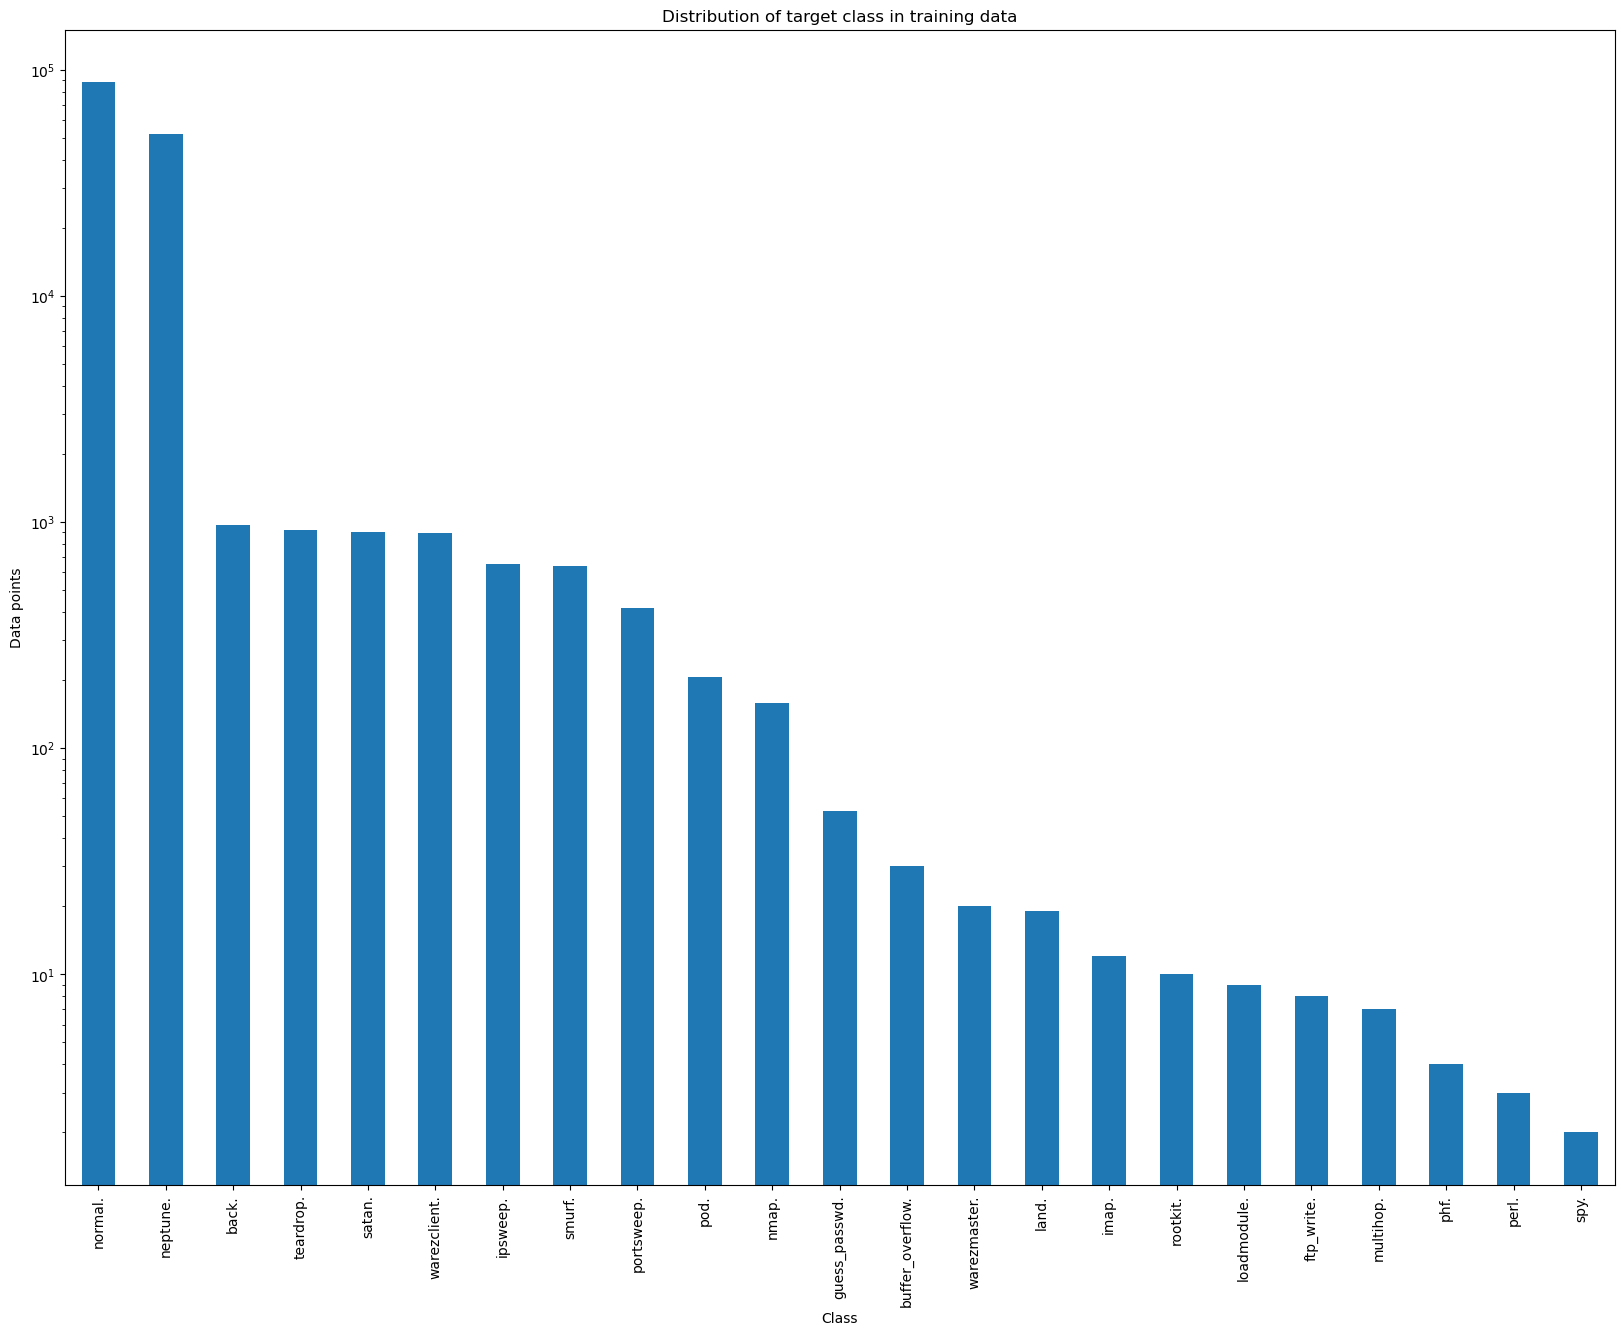

In [14]:
plt.figure(figsize=(20,15))
plt.yscale("log")
dist.plot(kind='bar')
plt.xlabel('Class')
plt.ylabel('Data points')
plt.title('Distribution of target class in training data')
plt.show()

([0,
  1,
  2,
  3,
  4,
  5,
  6,
  7,
  8,
  9,
  10,
  11,
  12,
  13,
  14,
  15,
  16,
  17,
  18,
  19,
  20,
  21,
  22],
 [Text(0, 0, 'normal.'),
  Text(1, 0, 'buffer_overflow.'),
  Text(2, 0, 'loadmodule.'),
  Text(3, 0, 'perl.'),
  Text(4, 0, 'neptune.'),
  Text(5, 0, 'smurf.'),
  Text(6, 0, 'guess_passwd.'),
  Text(7, 0, 'pod.'),
  Text(8, 0, 'teardrop.'),
  Text(9, 0, 'portsweep.'),
  Text(10, 0, 'ipsweep.'),
  Text(11, 0, 'land.'),
  Text(12, 0, 'ftp_write.'),
  Text(13, 0, 'back.'),
  Text(14, 0, 'imap.'),
  Text(15, 0, 'satan.'),
  Text(16, 0, 'phf.'),
  Text(17, 0, 'nmap.'),
  Text(18, 0, 'multihop.'),
  Text(19, 0, 'warezmaster.'),
  Text(20, 0, 'warezclient.'),
  Text(21, 0, 'spy.'),
  Text(22, 0, 'rootkit.')])

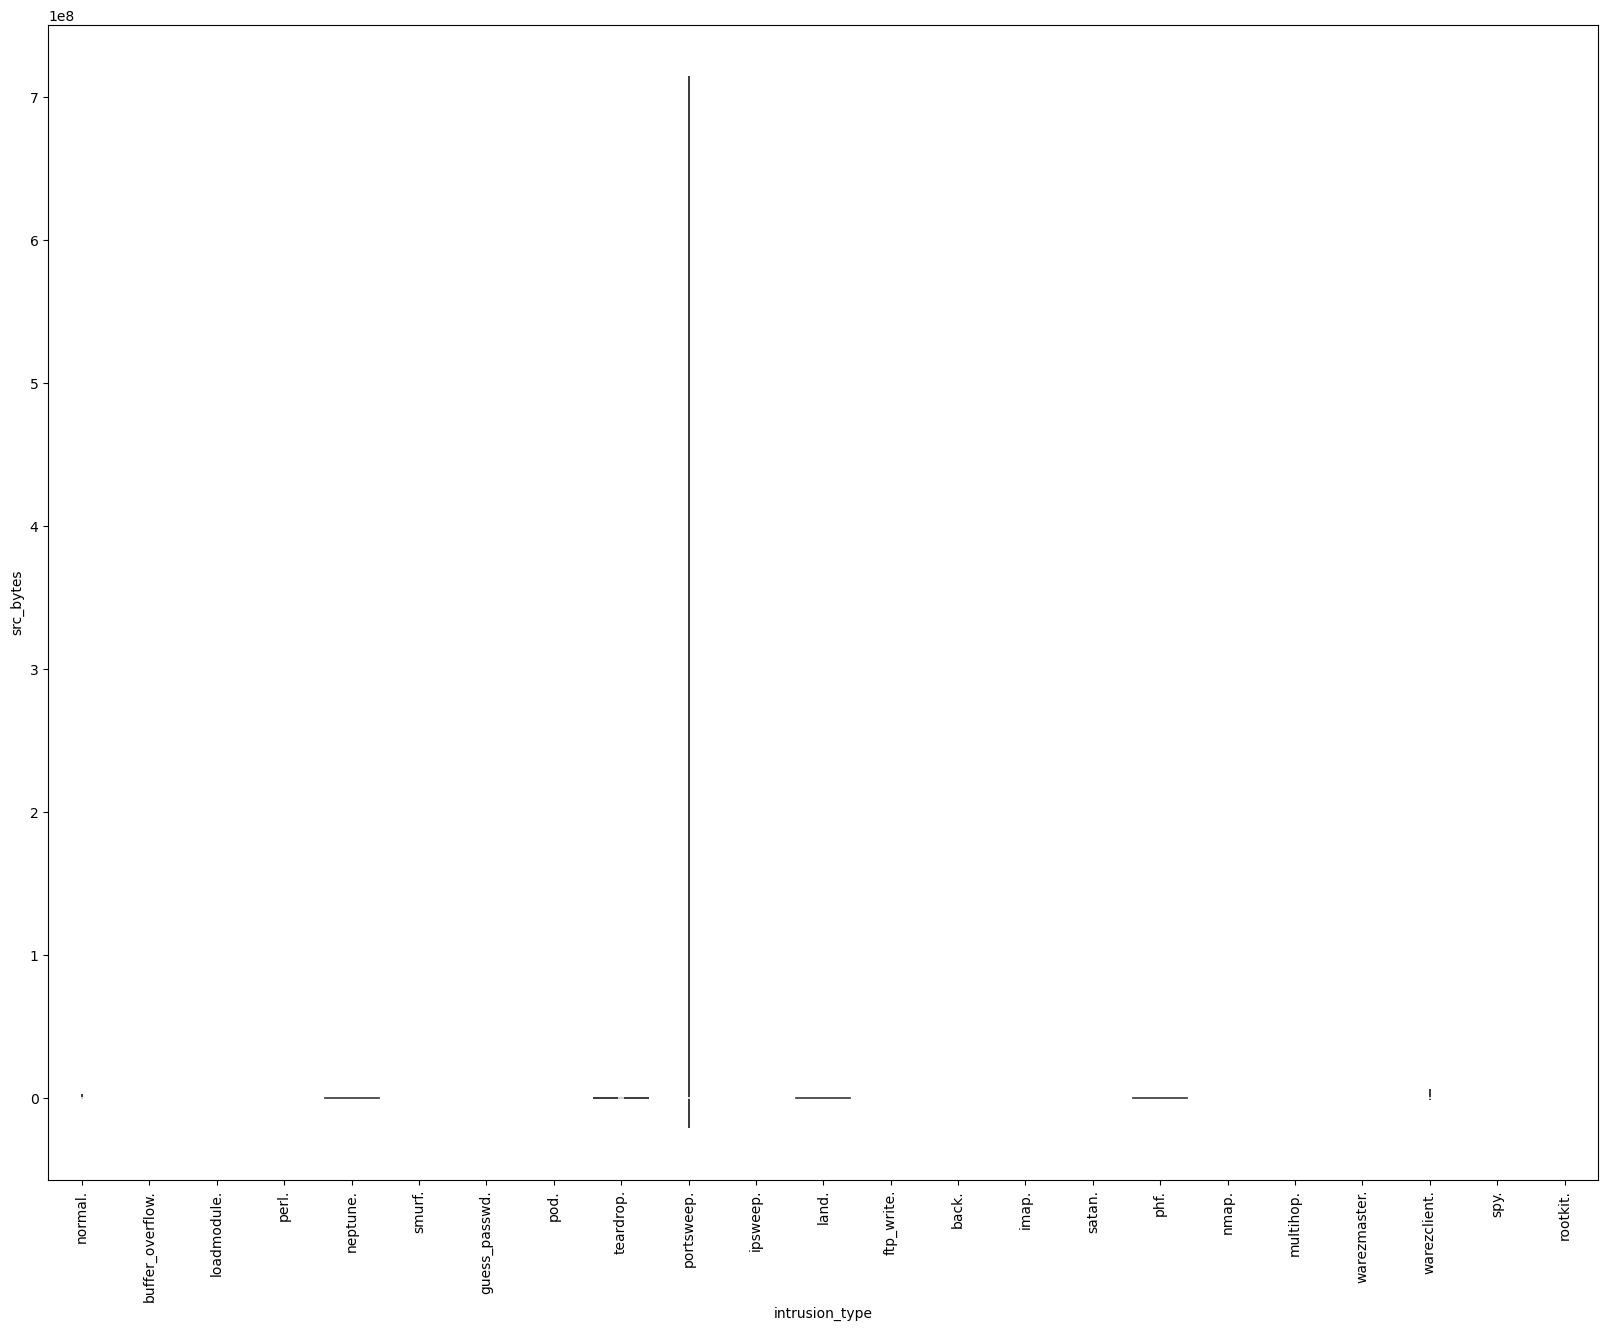

In [15]:
plt.figure(figsize=(20,15))
sns.violinplot(x="intrusion_type", y="src_bytes", data=df)
plt.xticks(rotation=90)

([0,
  1,
  2,
  3,
  4,
  5,
  6,
  7,
  8,
  9,
  10,
  11,
  12,
  13,
  14,
  15,
  16,
  17,
  18,
  19,
  20,
  21,
  22],
 [Text(0, 0, 'normal.'),
  Text(1, 0, 'buffer_overflow.'),
  Text(2, 0, 'loadmodule.'),
  Text(3, 0, 'perl.'),
  Text(4, 0, 'neptune.'),
  Text(5, 0, 'smurf.'),
  Text(6, 0, 'guess_passwd.'),
  Text(7, 0, 'pod.'),
  Text(8, 0, 'teardrop.'),
  Text(9, 0, 'portsweep.'),
  Text(10, 0, 'ipsweep.'),
  Text(11, 0, 'land.'),
  Text(12, 0, 'ftp_write.'),
  Text(13, 0, 'back.'),
  Text(14, 0, 'imap.'),
  Text(15, 0, 'satan.'),
  Text(16, 0, 'phf.'),
  Text(17, 0, 'nmap.'),
  Text(18, 0, 'multihop.'),
  Text(19, 0, 'warezmaster.'),
  Text(20, 0, 'warezclient.'),
  Text(21, 0, 'spy.'),
  Text(22, 0, 'rootkit.')])

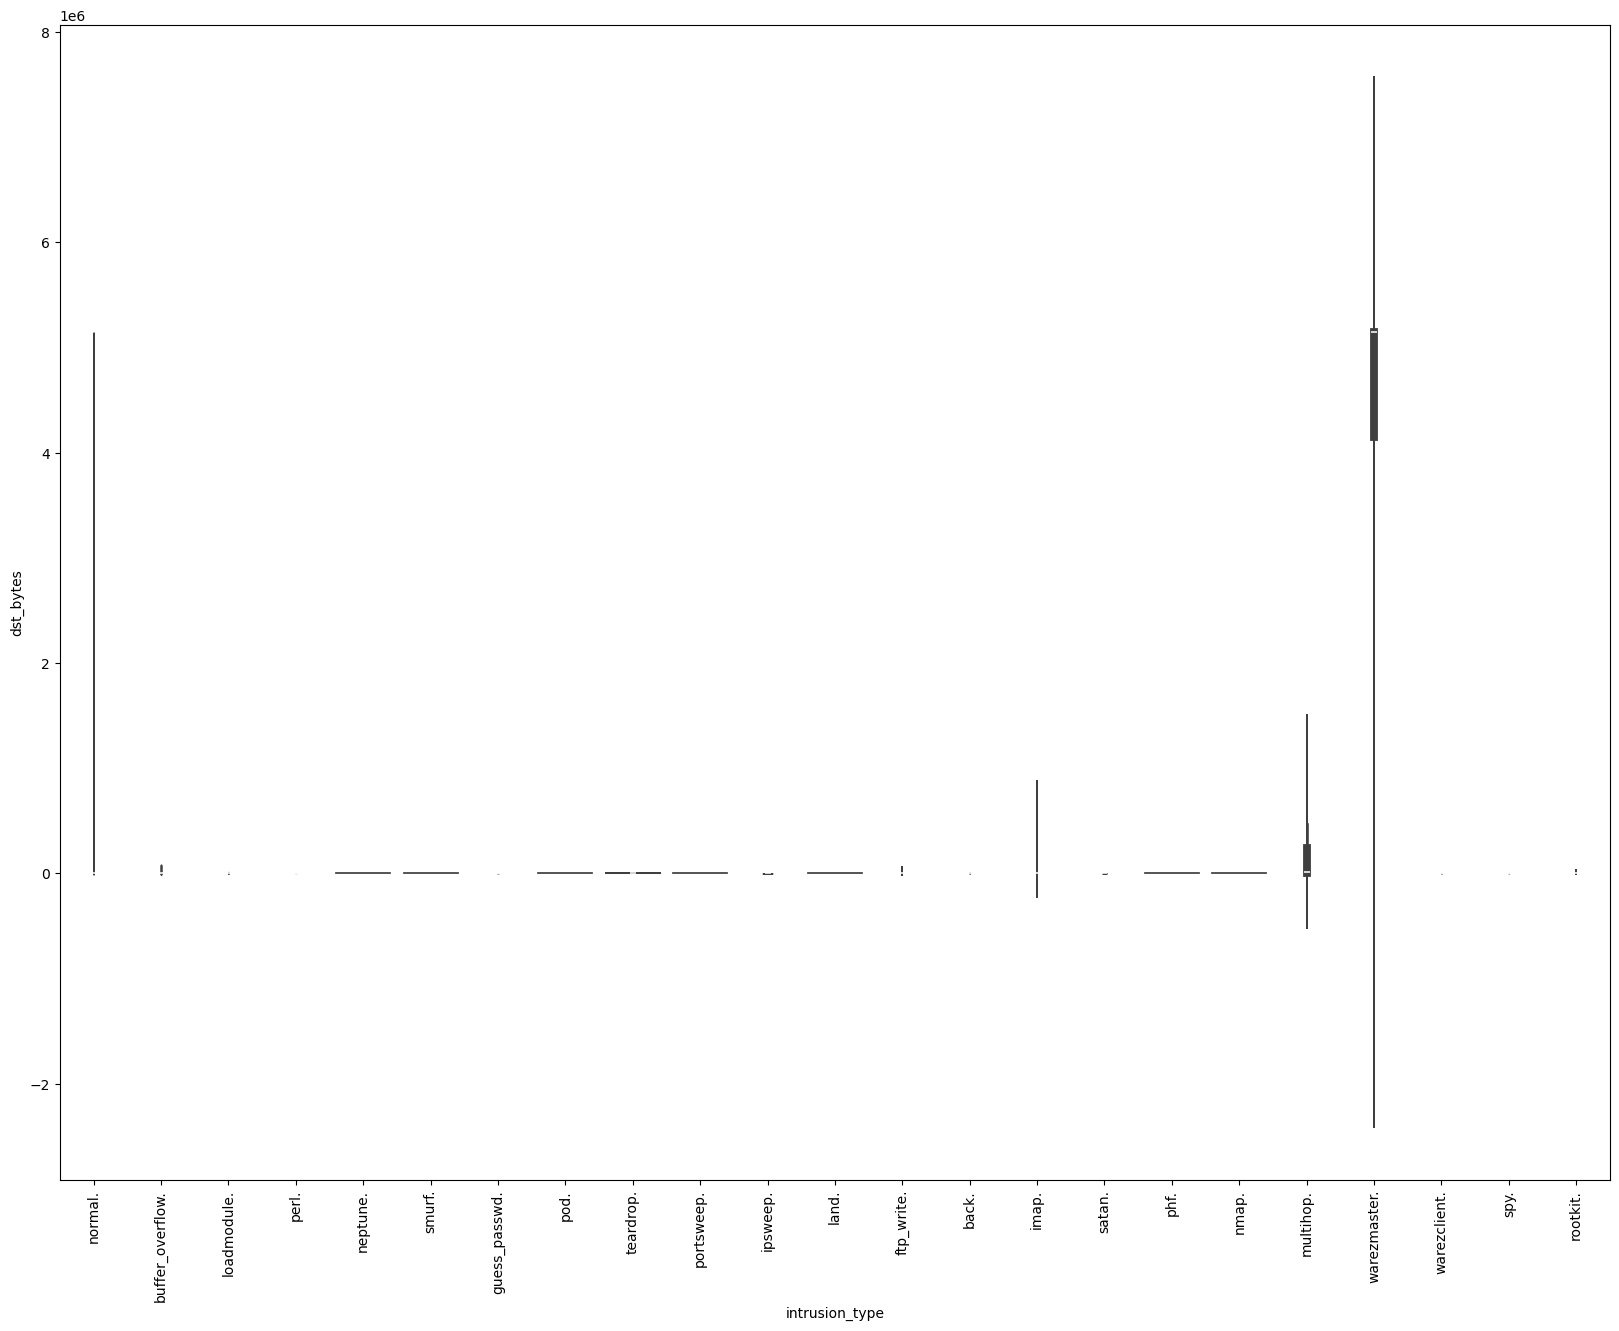

In [16]:
plt.figure(figsize=(20,15))
sns.violinplot(x="intrusion_type", y="dst_bytes", data=df)
plt.xticks(rotation=90)

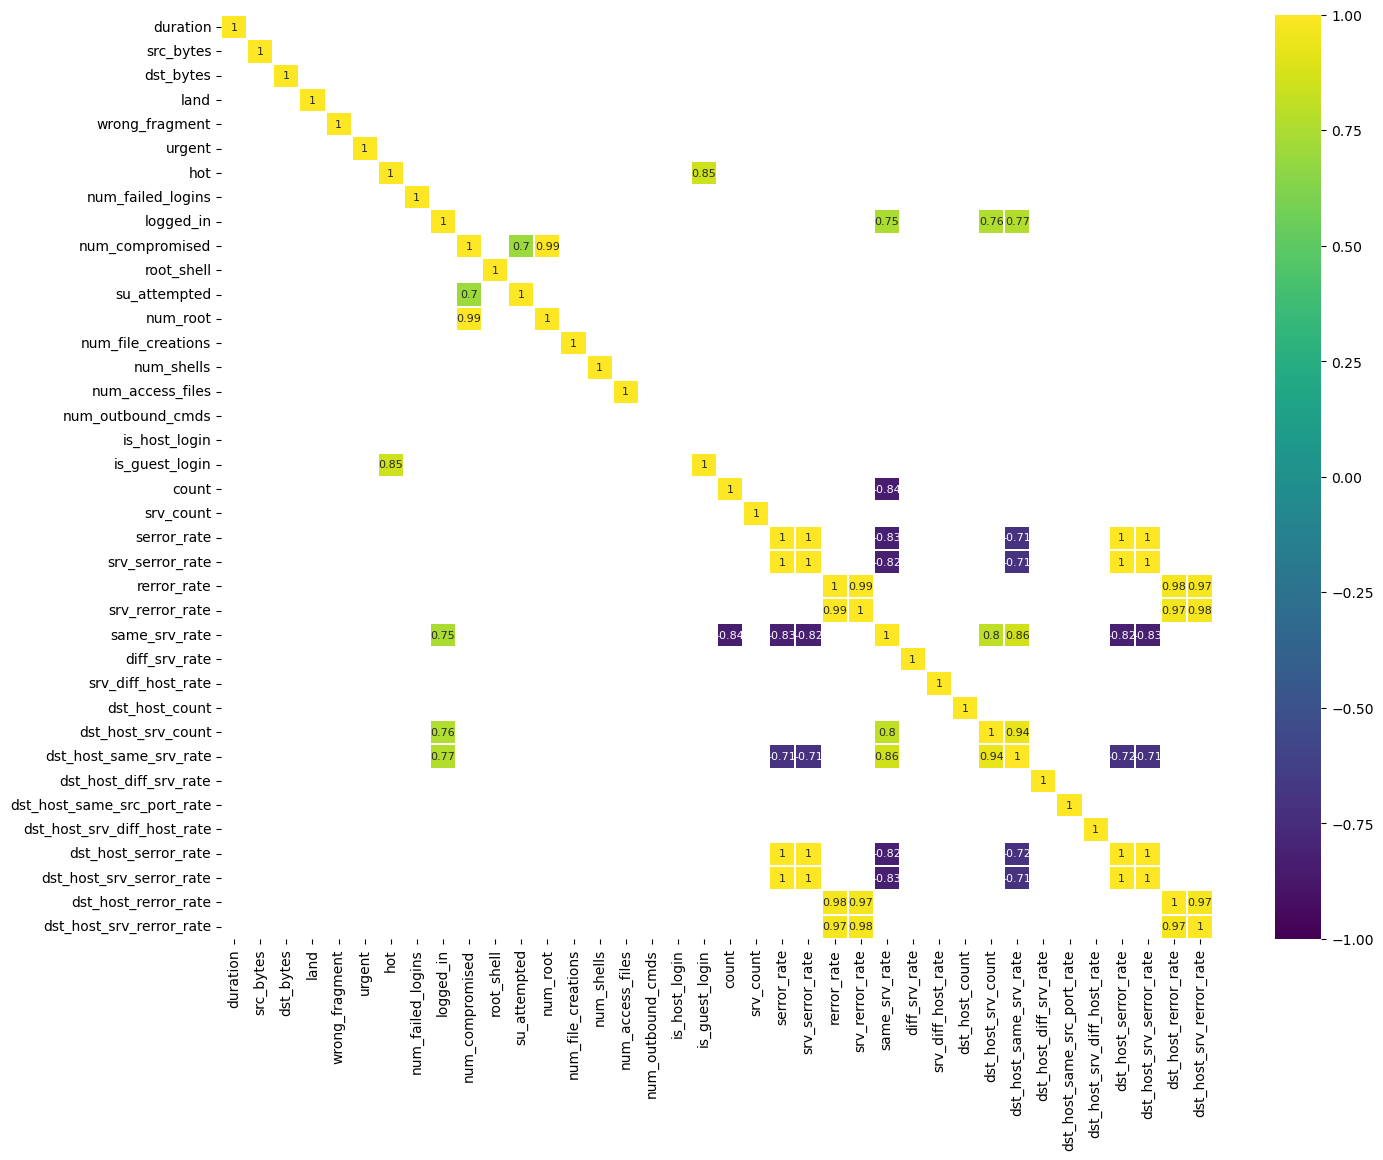

In [17]:
df_num = df.select_dtypes(include = ['float64', 'int64'])
corr = df_num.corr()
plt.figure(figsize=(16, 12))

sns.heatmap(corr[(corr >= 0.7) | (corr <= -0.7)], 
            cmap='viridis', vmax=1.0, vmin=-1.0, linewidths=0.1,
            annot=True, annot_kws={"size": 8});

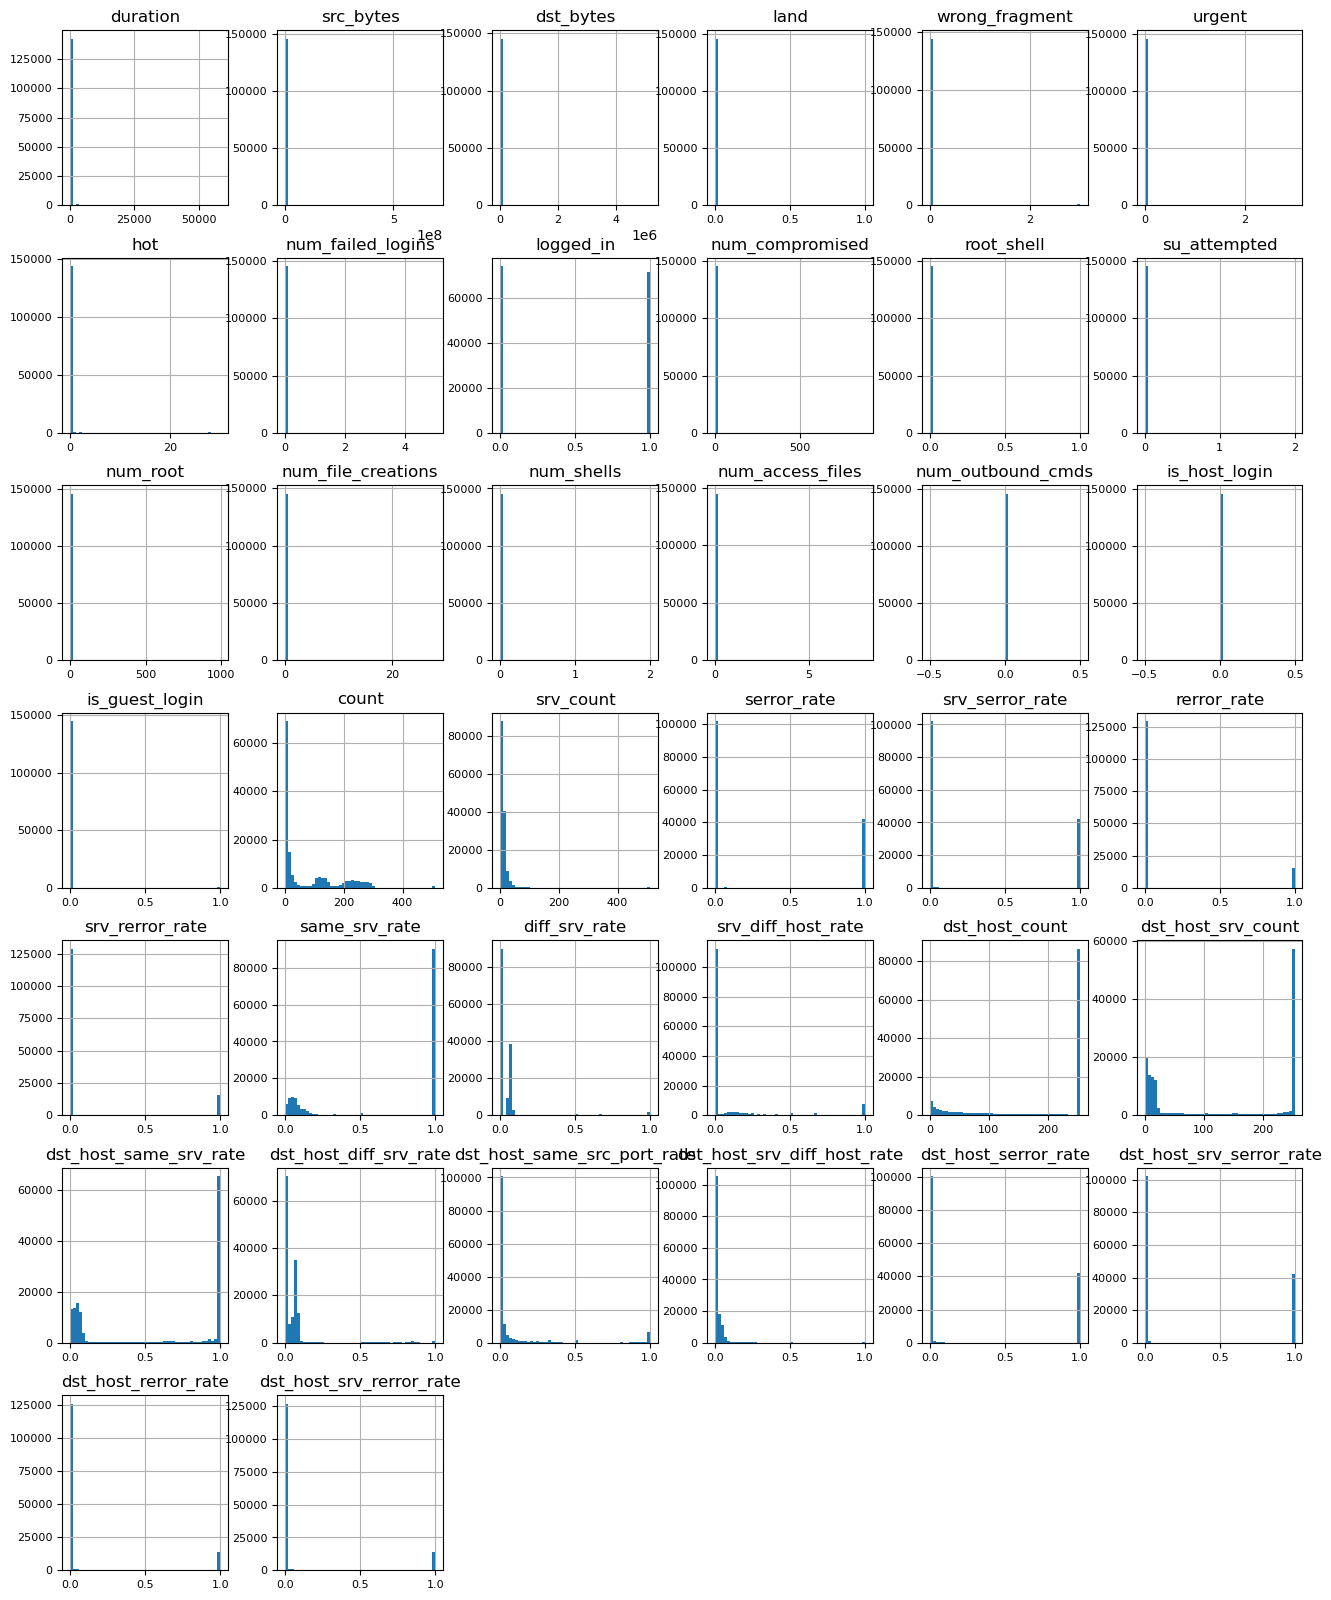

In [18]:
df_num.hist(figsize=(16, 20), bins=50, xlabelsize=8, ylabelsize=8);

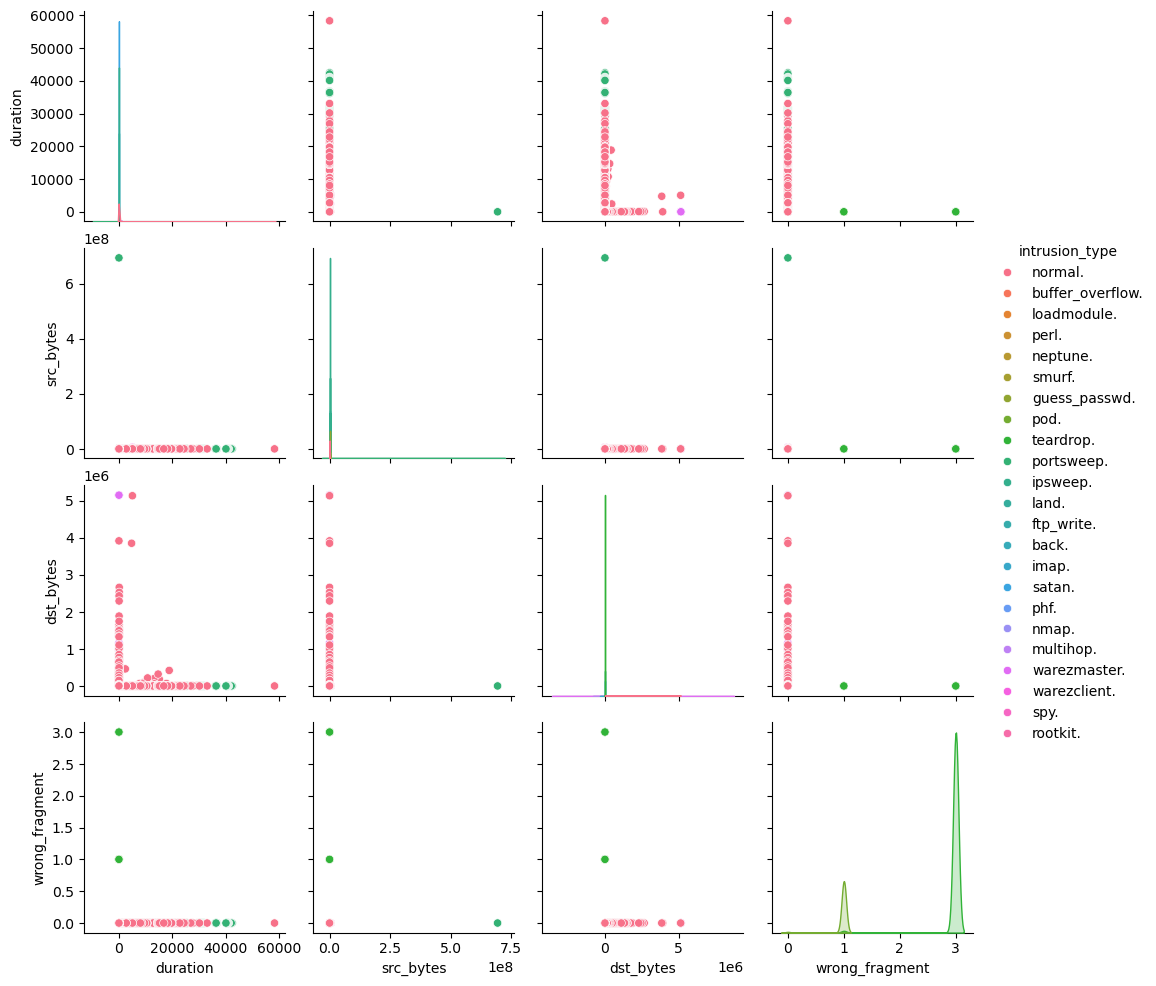

In [19]:
sns.pairplot(df, hue='intrusion_type', vars=['duration', 'src_bytes', 'dst_bytes', 'wrong_fragment'])

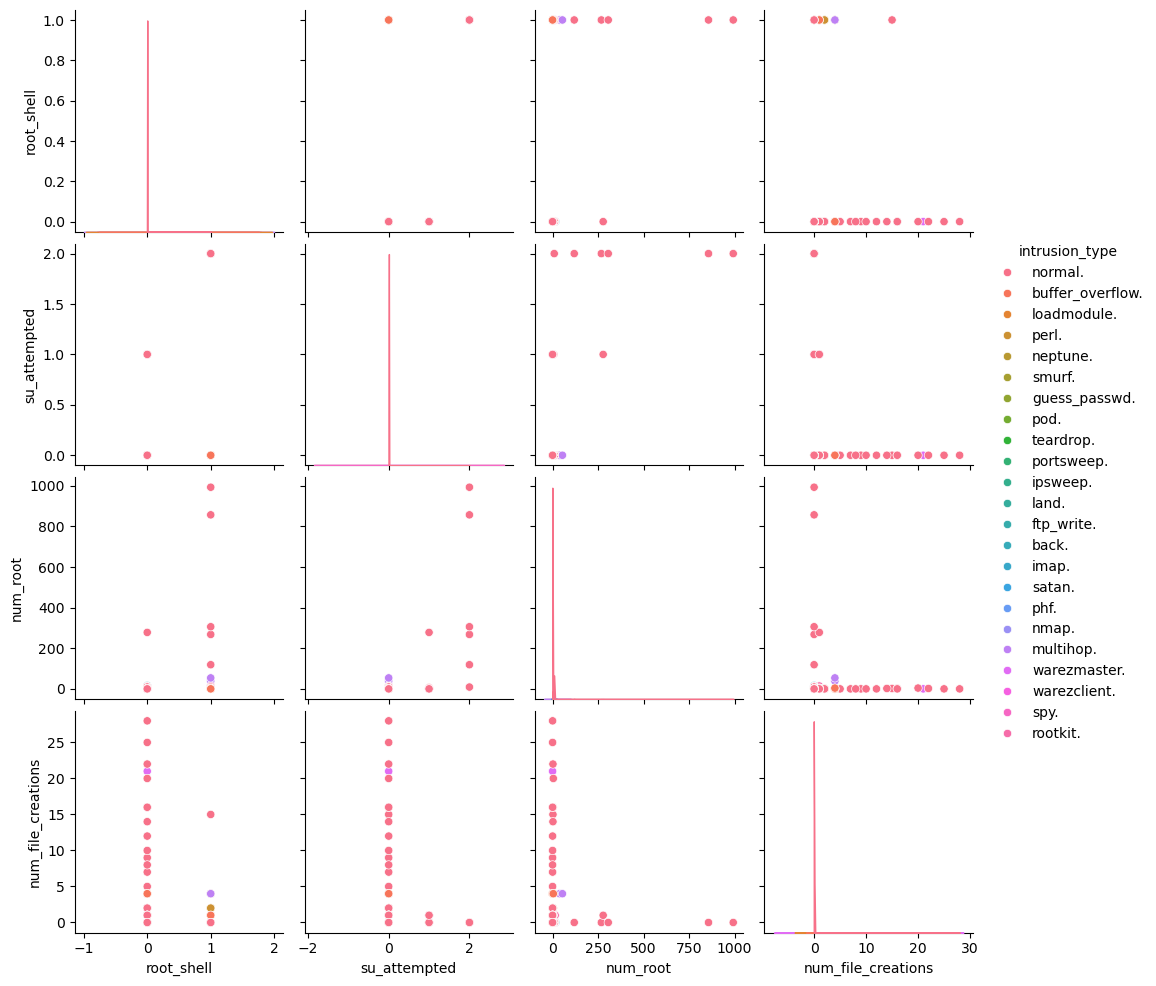

In [20]:
sns.pairplot(df, hue='intrusion_type', vars=['root_shell','su_attempted','num_root','num_file_creations'])

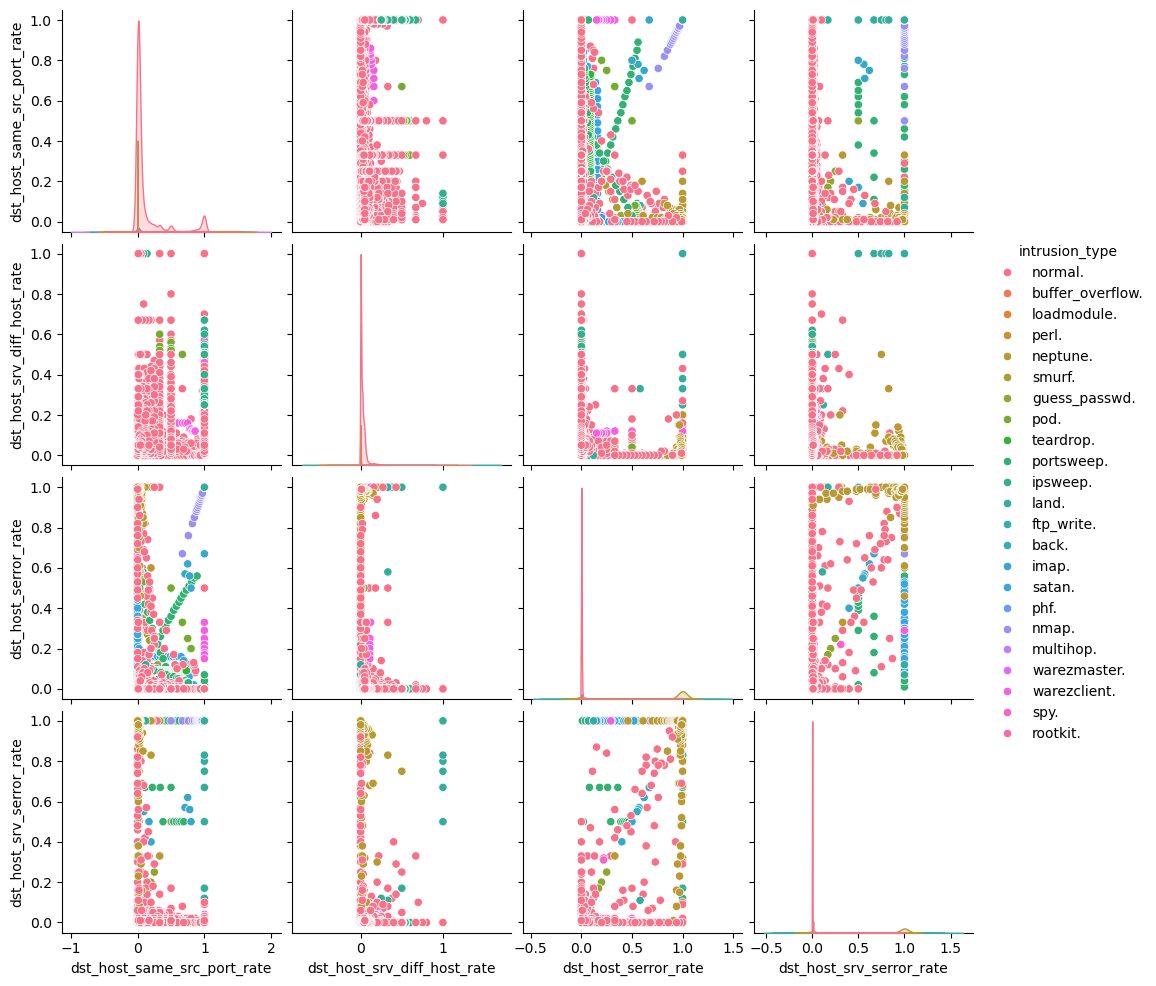

In [21]:
sns.pairplot(df, hue='intrusion_type', vars=['dst_host_same_src_port_rate','dst_host_srv_diff_host_rate',
                                             'dst_host_serror_rate','dst_host_srv_serror_rate'])

In [22]:
from sklearn.manifold import TSNE
tsne = TSNE(n_components = 2, perplexity = 50, n_iter = 1000)

In [23]:
frames = []
for label in df['intrusion_type'].unique():
    temp = df[df['intrusion_type'] == label]
    if label in ['normal.', 'neptune.']:  
        temp = temp.iloc[:10000, ]
    frames.append(temp)  

temp_df = pd.concat(frames)

df_num = temp_df.select_dtypes(include=['float64', 'int64'])

tsne_df = tsne.fit_transform(df_num)
print(tsne_df.shape)



(25934, 2)


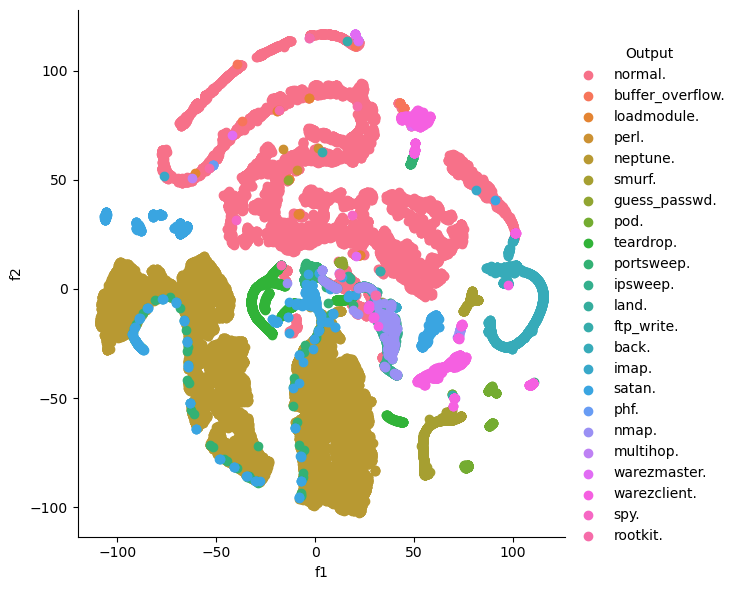

In [24]:
tsne_df = np.column_stack((tsne_df, temp_df['intrusion_type'].values))
tsne_dataset = pd.DataFrame(tsne_df, columns=['f1', 'f2', 'Output'])
sns.FacetGrid(tsne_dataset, hue='Output', height=6).map(plt.scatter, 'f1', 'f2').add_legend()
plt.show()

In [25]:
from sklearn.decomposition import PCA
pca = PCA(n_components = 2)

In [26]:
from sklearn.preprocessing import StandardScaler
X = StandardScaler().fit_transform(df.select_dtypes(include = ['float64', 'int64']))

In [27]:
pca_df = pca.fit_transform(X)
pca_df.shape

(145586, 2)

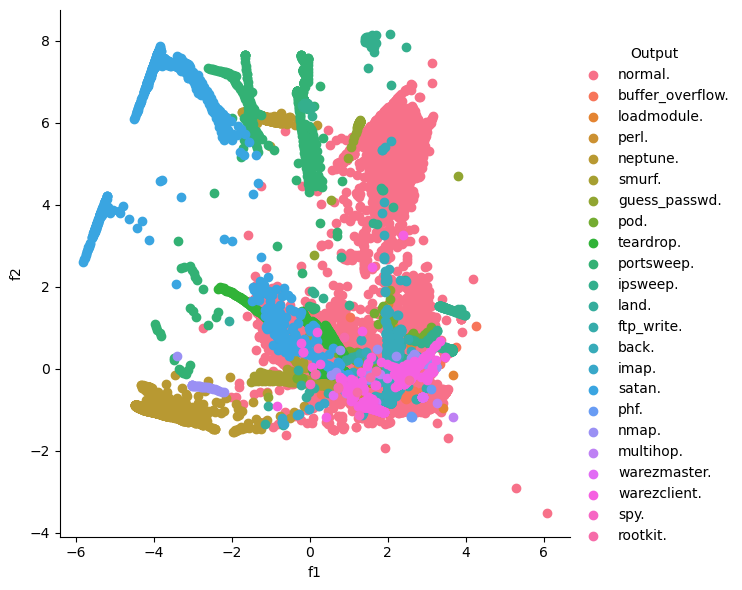

In [28]:
pca_df = np.vstack((pca_df[:, :2].T, df['intrusion_type'].values)).T
pca_dataset = pd.DataFrame(data=pca_df, columns=['f1', 'f2', 'Output'])
sns.FacetGrid(pca_dataset, hue='Output', height=6).map(plt.scatter, 'f1', 'f2').add_legend()
plt.show()

In [29]:
pd.crosstab(df.protocol_type, df.intrusion_type)

intrusion_type,back.,buffer_overflow.,ftp_write.,guess_passwd.,imap.,ipsweep.,land.,loadmodule.,multihop.,neptune.,nmap.,normal.,perl.,phf.,pod.,portsweep.,rootkit.,satan.,smurf.,spy.,teardrop.,warezclient.,warezmaster.
protocol_type,,,,,,,,,,,,,,,,,,,,,,,
icmp,0,0,0,0,0,560,0,0,0,0,103,892,0,0,206,1,0,3,641,0,0,0,0
tcp,968,30,8,53,12,91,19,9,7,51820,30,75789,3,4,0,415,7,733,0,2,0,893,20
udp,0,0,0,0,0,0,0,0,0,0,25,11151,0,0,0,0,3,170,0,0,918,0,0


In [30]:
pd.crosstab(df.root_shell, df.intrusion_type)

intrusion_type,back.,buffer_overflow.,ftp_write.,guess_passwd.,imap.,ipsweep.,land.,loadmodule.,multihop.,neptune.,nmap.,normal.,perl.,phf.,pod.,portsweep.,rootkit.,satan.,smurf.,spy.,teardrop.,warezclient.,warezmaster.
root_shell,,,,,,,,,,,,,,,,,,,,,,,
0,968,12,8,53,12,651,19,6,5,51820,158,87809,0,0,206,416,8,906,641,2,918,893,20
1,0,18,0,0,0,0,0,3,2,0,0,23,3,4,0,0,2,0,0,0,0,0,0


In [31]:
pd.crosstab(df.flag, df.intrusion_type)

intrusion_type,back.,buffer_overflow.,ftp_write.,guess_passwd.,imap.,ipsweep.,land.,loadmodule.,multihop.,neptune.,nmap.,normal.,perl.,phf.,pod.,portsweep.,rootkit.,satan.,smurf.,spy.,teardrop.,warezclient.,warezmaster.
flag,,,,,,,,,,,,,,,,,,,,,,,
OTH,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,6,0,0,0,0,0,0,0
REJ,0,0,0,0,0,80,0,0,0,9349,0,4655,0,0,0,74,0,554,0,0,0,0,0
RSTO,0,1,0,45,0,3,0,0,0,446,0,66,0,0,0,7,0,0,0,0,0,1,0
RSTOS0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,11,0,0,0,0,0,0,0
RSTR,90,0,0,4,0,0,0,0,0,0,0,31,0,0,0,299,0,0,0,0,0,1,0
S0,0,0,0,0,1,0,19,0,0,42025,0,51,0,0,0,18,0,164,0,0,0,0,0
S1,2,0,0,0,1,0,0,0,0,0,0,54,0,0,0,0,0,0,0,0,0,0,0
S2,5,0,0,0,0,0,0,0,0,0,0,17,0,0,0,0,0,1,0,0,0,1,0
S3,0,0,0,2,0,0,0,0,0,0,0,7,0,0,0,0,0,0,0,0,0,1,0


# Model Building

In [32]:
target = []
for label in df['intrusion_type'].values:
    if label == 'normal.':
        target.append(1)
    else:
        target.append(0)

In [33]:
def train_test(df, stratify_col, split):
    train_indices, test_indices = np.array([]), np.array([])
    
    for class_name, val in df[stratify_col].value_counts().items(): 
        class_samples_indices = df[df[stratify_col] == class_name].index.values
        
        class_test_indices = np.random.choice(class_samples_indices,
                            size = int(np.ceil(split * val)), replace = False)
        class_train_indices = np.setdiff1d(class_samples_indices, class_test_indices)
        
        test_indices = np.append(test_indices, class_test_indices)
        train_indices = np.append(train_indices, class_train_indices)

    print(test_indices.shape, train_indices.shape)
    x_train = df.iloc[train_indices, :-1]
    y_train = df.iloc[train_indices, -1]
    x_test = df.iloc[test_indices, :-1]
    y_test = df.iloc[test_indices, -1]
    
    return x_train, y_train, x_test, y_test

def confusion_matrix(y_test, y_pred, model):
    tp, tn, fp, fn = 0, 0, 0, 0
    for i in range(len(y_test)):
        if y_test[i] == 1 and y_pred[i] == 1:
            tp += 1
        
        if y_test[i] == 0 and y_pred[i] == 0:
            tn += 1
            
        if y_test[i] == 0 and y_pred[i] == 1:
            fp += 1
            
        if y_test[i] == 1 and y_pred[i] == 0:
            fn += 1
            
    matrix = [[tn, fp], [fn, tp]]
    cm_df = pd.DataFrame(matrix)
    labels = ['BAD', 'NORMAL']
    plt.figure(figsize=(3,3))
    sns.heatmap(cm_df, annot=True, annot_kws={"size":12}, fmt='g', xticklabels=labels, yticklabels=labels)
    plt.ylabel('Actual Class')
    plt.xlabel('Predicted Class')
    plt.title(model)
    plt.show()
    
    return fp

def accuracy(y_test, y_pred):
    return round(np.sum(y_test == y_pred)/y_test.shape[0] * 100, 2)

## Gaussian naive bayes

In [34]:
df_gnb = df.select_dtypes(include = ['float64', 'int64'])
print(df_gnb.columns)

var_threshold = 0.98
pca_obj = PCA(n_components=var_threshold)
num_features_transformed = pca_obj.fit_transform(StandardScaler().fit_transform(df_gnb)) 

df_gnb = pd.DataFrame(num_features_transformed)
df_gnb['target'] = target

df_gnb.to_pickle('gnb_dataset.pkl')

Index(['duration', 'src_bytes', 'dst_bytes', 'land', 'wrong_fragment',
       'urgent', 'hot', 'num_failed_logins', 'logged_in', 'num_compromised',
       'root_shell', 'su_attempted', 'num_root', 'num_file_creations',
       'num_shells', 'num_access_files', 'num_outbound_cmds', 'is_host_login',
       'is_guest_login', 'count', 'srv_count', 'serror_rate',
       'srv_serror_rate', 'rerror_rate', 'srv_rerror_rate', 'same_srv_rate',
       'diff_srv_rate', 'srv_diff_host_rate', 'dst_host_count',
       'dst_host_srv_count', 'dst_host_same_srv_rate',
       'dst_host_diff_srv_rate', 'dst_host_same_src_port_rate',
       'dst_host_srv_diff_host_rate', 'dst_host_serror_rate',
       'dst_host_srv_serror_rate', 'dst_host_rerror_rate',
       'dst_host_srv_rerror_rate'],
      dtype='object')


In [35]:

class GNB:
    def __init__(self, prior=None, n_class=None, mean=None, variance = None, classes=None):
        self.prior = prior
        self.n_class = n_class
        self.mean = mean
        self.variance = variance
        self.classes = classes

    def fit(self, x, y):
        self.x = x
        self.y = y
        self.mean = np.array(x.groupby(by=y).mean())
        self.variance = np.array(x.groupby(by=y).var())
        self.n_class = len(np.unique(self.y))
        self.classes = np.unique(self.y)
        self.prior = 1/self.n_class

    def calc_mean_var(self):
        m = np.array(self.mean)
        v = np.array(self.variance)

        self.mean_var = []
        for i in range(len(m)):
            m_row = m[i]
            v_row = v[i]
            for a, b in enumerate(m_row):
                mean = b
                var = v_row[a]
                self.mean_var.append([mean, var])
        return self.mean_var

    def split(self):
        spt = np.vsplit(np.array(self.calc_mean_var()), self.n_class)
        return spt

    def gnb_base(self, x_val, x_mean, x_var):
        self.x_val = x_val
        self.x_mean = x_mean
        self.x_var = x_var
        
        pi = np.pi
        equation_1 = 1/(np.sqrt(2 * pi * x_var))
        denom = 2 * x_var
        numerator = (x_val - x_mean) ** 2
        expo = np.exp(-(numerator/denom))
        prob = equation_1 * expo

        return prob

    def predict(self, X):
        self.X = X
        split_class = self.split()
        prob = []
        for i in range(self.n_class):
            class_one = split_class[i]
            for i in range(len(class_one)):
                class_one_x_mean = class_one[i][0]
                class_one_x_var = class_one[i][1]
                x_value = X[i] 
                prob.append([self.gnb_base(x_value, class_one_x_mean, class_one_x_var)])

        prob_array = np.array(prob)
        prob_split = np.vsplit(prob_array, self.n_class)
        final_probabilities = []
        for i in prob_split:
            class_prob = np.prod(i) * self.prior
            final_probabilities.append(class_prob)

        maximum_prob = max(final_probabilities)
        prob_index = final_probabilities.index(maximum_prob)
        prediction = self.classes[prob_index]
        return prediction

## Decision Tree

In [36]:
df_dt = df.drop('intrusion_type', axis = 1)
df_dt['target'] = target
df_dt.to_pickle('dt_dataset.pkl')

In [37]:

def unique_vals(rows, col):
    return set([row[col] for row in rows])

def class_counts(rows):
    counts = {} 
    for row in rows:
        label = row[-1]
        if label not in counts:
            counts[label] = 0
        counts[label] += 1
    return counts

def is_numeric(value):
    return isinstance(value, int) or isinstance(value, float)

class Question:
    def __init__(self, column, value):
        self.column = column
        self.value = value

    def match(self, example):
        val = example[self.column]
        if is_numeric(val):
            return val >= self.value
        else:
            return val == self.value

def partition(rows, question):
    true_rows, false_rows = [], []
    for row in rows:
        if question.match(row):
            true_rows.append(row)
        else:
            false_rows.append(row)
    return true_rows, false_rows

def gini(rows):
    counts = class_counts(rows)
    impurity = 1
    for lbl in counts:
        prob_of_lbl = counts[lbl] / float(len(rows))
        impurity -= prob_of_lbl**2
    return impurity

def info_gain(left, right, current_uncertainty):
    p = float(len(left)) / (len(left) + len(right))
    return current_uncertainty - p * gini(left) - (1 - p) * gini(right)

def find_best_split(rows):
    best_gain = 0 
    best_question = None
    current_uncertainty = gini(rows)
    n_features = len(rows[0]) - 1 

    for col in range(n_features): 
        values = set([row[col] for row in rows]) 
        for val in values:
            question = Question(col, val)
  
            true_rows, false_rows = partition(rows, question)

            if len(true_rows) == 0 or len(false_rows) == 0:
                continue


            gain = info_gain(true_rows, false_rows, current_uncertainty)

            if gain >= best_gain:
                best_gain, best_question = gain, question

    return best_gain, best_question

class Leaf:
    def __init__(self, rows):
        self.predictions = class_counts(rows)

class Decision_Node:
    def __init__(self,
                 question,
                 true_branch,
                 false_branch):
        self.question = question
        self.true_branch = true_branch
        self.false_branch = false_branch

def build_tree(rows):
    gain, question = find_best_split(rows)
    if gain == 0:
        return Leaf(rows)
    
    true_rows, false_rows = partition(rows, question)

    true_branch = build_tree(true_rows)
    false_branch = build_tree(false_rows)

    return Decision_Node(question, true_branch, false_branch)

def classify(row, node):
    if isinstance(node, Leaf):
        return node.predictions

    if node.question.match(row):
        return classify(row, node.true_branch)
    else:
        return classify(row, node.false_branch)

## XGBoost

In [38]:
df_xgb = df.select_dtypes(include = ['float64', 'int64'])

var_threshold = 0.98
pca_obj = PCA(n_components=var_threshold)
num_features_transformed = pca_obj.fit_transform(StandardScaler().fit_transform(df_xgb)) 

df_xgb = pd.DataFrame(num_features_transformed)


from sklearn.feature_extraction.text import CountVectorizer

vocab = list(set(list(df['protocol_type'].values)))
one_hot = CountVectorizer(vocabulary=vocab, binary=True)
protocol_final = one_hot.fit_transform(df['protocol_type'].values)

vocab = list(set(list(df['service'].values)))
one_hot = CountVectorizer(vocabulary=vocab, binary=True)
service_final = one_hot.fit_transform(df['service'].values)

vocab = list(set(list(df['flag'].values)))
one_hot = CountVectorizer(vocabulary=vocab, binary=True)
flag_final = one_hot.fit_transform(df['flag'].values)

from scipy.sparse import hstack
df_xgb = hstack((df_xgb, protocol_final, service_final, flag_final))
df_xgb = pd.DataFrame(df_xgb.toarray())
df_xgb['target'] = target
df_xgb.to_pickle('xgb_dataset.pkl')

In [39]:
from xgboost import XGBClassifier

# Model Training & Testing

In [40]:
from collections import defaultdict
  
results = defaultdict(list)

### Gaussian naive bayes

(29118,) (116468,)
Accuracy: 96.39%


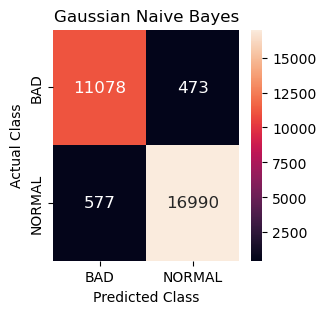

In [41]:
df = pd.read_pickle('gnb_dataset.pkl')

x_train, y_train, x_test, y_test = train_test(df=df, stratify_col='target', split=0.20)

gaussian_classifier = GNB()
gaussian_classifier.fit(x_train, y_train)
preds = []
for test in x_test.values:
    preds.append(gaussian_classifier.predict(test))
y_pred = np.array(preds)

acc = accuracy(y_test.values, y_pred)
print(f"Accuracy: {acc}%")

fp = confusion_matrix(y_test.values, y_pred, "Gaussian Naive Bayes")

results['Gaussian Naive Bayes'] = [acc, fp]

### Decision Tree

Accuracy: 99.74%


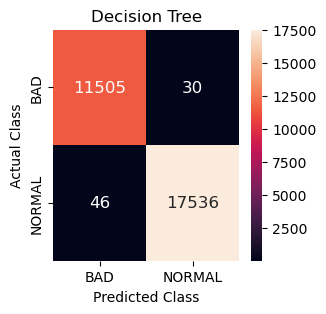

In [42]:
df = pd.read_pickle('dt_dataset.pkl')
df = df.sample(frac=1).reset_index(drop=True)

training_data = df.iloc[:10000, :].values.tolist()
testing_data = df.iloc[int(np.ceil(.80 * df.shape[0])):, :].values.tolist()

my_tree = build_tree(training_data)

actual, predicted = [], []
for row in testing_data:
    actual.append(row[-1])
    predicted.append(sorted(classify(row, my_tree).items(), key = lambda x: x[1], reverse = True)[0][0])

acc = accuracy(np.array(actual), np.array(predicted))
print(f"Accuracy: {acc}%")

fp = confusion_matrix(np.array(actual), np.array(predicted), "Decision Tree")

results['Decision Tree'] = [acc, fp]

### XGBoost

(29118,) (116468,)
Accuracy: 99.9%


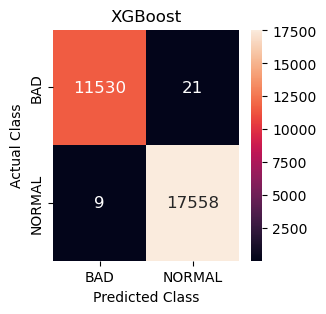

In [43]:
df = pd.read_pickle('xgb_dataset.pkl')
x_train, y_train, x_test, y_test = train_test(df=df, stratify_col='target', split=0.20)

model = XGBClassifier()
model.fit(x_train, y_train)
y_pred = model.predict(x_test)

acc = accuracy(y_test.values, y_pred)
print(f"Accuracy: {acc}%")

fp = confusion_matrix(y_test.values, y_pred, "XGBoost")

results['XGBoost'] = [acc, fp]

### Max-Voting Ensemble Technique

Accuracy: 99.93%


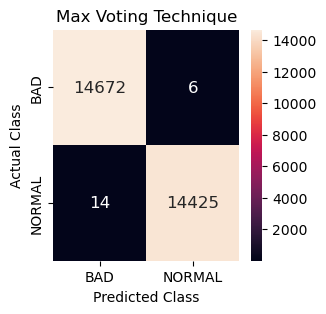

In [44]:
df = pd.read_pickle('gnb_dataset.pkl')
preds = []
test_set = df.iloc[int(np.ceil(.80 * df.shape[0])):, :-1]
for test in test_set.values:
    preds.append(gaussian_classifier.predict(test))
gnb_preds = np.array(preds)

df = pd.read_pickle('dt_dataset.pkl')
test_set = df.iloc[int(np.ceil(.80 * df.shape[0])):, :].values.tolist()
predicted = []
for row in test_set:
    predicted.append(sorted(classify(row, my_tree).items(), key = lambda x: x[1], reverse = True)[0][0])
dt_preds = np.array(predicted)
    
df = pd.read_pickle('xgb_dataset.pkl')
test_set = df.iloc[int(np.ceil(.80 * df.shape[0])):, :-1]
xgb_preds = model.predict(test_set)

y_test_pred_maxvote = []
for tup in list(zip(gnb_preds, dt_preds, xgb_preds)):
    y_test_pred_maxvote.append(np.bincount(tup).argmax())
max_vote_preds = np.array(y_test_pred_maxvote)

y_test = df.iloc[int(np.ceil(.80 * df.shape[0])):, -1]

acc = accuracy(y_test.values, max_vote_preds)
print(f"Accuracy: {acc}%")

fp = confusion_matrix(y_test.values, max_vote_preds, "Max Voting Technique")

results['Max Voting Technique'] = [acc, fp]

In [45]:
from prettytable import PrettyTable
x = PrettyTable()
x.field_names = ["Technique", "Accuracy", "False Positives"]
x.add_row(['Gaussian Naive Bayes'] + results['Gaussian Naive Bayes'])
x.add_row(['Decision Tree']  + results['Decision Tree'])
x.add_row(['XGBoost'] + results['XGBoost'])
x.add_row(['Max Voting Technique'] + results['Max Voting Technique'])
print(x)

+----------------------+----------+-----------------+
|      Technique       | Accuracy | False Positives |
+----------------------+----------+-----------------+
| Gaussian Naive Bayes |  96.39   |       473       |
|    Decision Tree     |  99.74   |        30       |
|       XGBoost        |   99.9   |        21       |
| Max Voting Technique |  99.93   |        6        |
+----------------------+----------+-----------------+
